In [1]:
import pandas as pd

# What is the dynamic range of GCN4 TREBL - seq?

In [40]:
df = pd.read_csv("../../output/GCN4_pipeline/time_normalization/DBD_time_normalized_activities_bootstrapped_error_and_no_CIs.csv")
df

,Unnamed: 0,ADseq,time,mean,ci_low,ci_hi,n_barcodes
0,0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-0.533217,-1.199781,0.131956,2
1,1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,0.036563,-0.531644,0.509437,2
2,2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,0.432846,0.035151,0.703783,2
3,3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,0.317114,-0.175927,0.829249,2
4,4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,0.469307,-0.223151,1.221027,2
...,...,...,...,...,...,...,...
77728,50172,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,10,-0.496125,NaN,NaN,1
77729,50173,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,15,-0.554889,NaN,NaN,1
77730,50174,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,30,-0.376546,NaN,NaN,1
77731,50175,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,180,-0.636271,NaN,NaN,1


In [41]:
# get t=0 baseline for each tile
t0 = (
    df[df["time"] == 0]
    [["ADseq", "mean"]]
    .rename(columns={"mean": "mean_t0"})
)
t0

,ADseq,mean_t0
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,-0.533217
7,AAAYSVEPKKPIVQTPASPASPRAKRSVASSPVPASGGVK,-0.206253
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0.603252
21,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,-0.068038
28,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,-0.303746
...,...,...
77698,YVEGLRWVTWGQMGHVELSPVSRFTATIPSHDFQSFVTDH,0.001652
77705,YVIRLSGYMFFGTIASVEKFVRELLSEDSFSRQPIRFLIL,-1.145860
77712,YWSHPTLKHTRPNTASVPSNSPNTNRPPIPLFNGQQNHNQ,1.354791
77719,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,0.040089


In [42]:
# merge baseline onto all rows
tmp = df.merge(t0, on="ADseq", how="left")
tmp

,Unnamed: 0,ADseq,time,mean,ci_low,ci_hi,n_barcodes,mean_t0
0,0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-0.533217,-1.199781,0.131956,2,-0.533217
1,1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,0.036563,-0.531644,0.509437,2,-0.533217
2,2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,0.432846,0.035151,0.703783,2,-0.533217
3,3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,0.317114,-0.175927,0.829249,2,-0.533217
4,4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,0.469307,-0.223151,1.221027,2,-0.533217
...,...,...,...,...,...,...,...,...
77728,50172,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,10,-0.496125,NaN,NaN,1,-0.109257
77729,50173,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,15,-0.554889,NaN,NaN,1,-0.109257
77730,50174,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,30,-0.376546,NaN,NaN,1,-0.109257
77731,50175,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,180,-0.636271,NaN,NaN,1,-0.109257


In [43]:
# compute rise relative to t=0
tmp["rise_from_t0"] = tmp["mean"] - tmp["mean_t0"]
tmp

,Unnamed: 0,ADseq,time,mean,ci_low,ci_hi,n_barcodes,mean_t0,rise_from_t0
0,0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-0.533217,-1.199781,0.131956,2,-0.533217,0.000000
1,1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,0.036563,-0.531644,0.509437,2,-0.533217,0.569780
2,2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,0.432846,0.035151,0.703783,2,-0.533217,0.966063
3,3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,0.317114,-0.175927,0.829249,2,-0.533217,0.850330
4,4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,0.469307,-0.223151,1.221027,2,-0.533217,1.002523
...,...,...,...,...,...,...,...,...,...
77728,50172,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,10,-0.496125,NaN,NaN,1,-0.109257,-0.386869
77729,50173,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,15,-0.554889,NaN,NaN,1,-0.109257,-0.445632
77730,50174,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,30,-0.376546,NaN,NaN,1,-0.109257,-0.267290
77731,50175,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,180,-0.636271,NaN,NaN,1,-0.109257,-0.527014


In [44]:
tmp = tmp.dropna(subset = "rise_from_t0")
tmp

,Unnamed: 0,ADseq,time,mean,ci_low,ci_hi,n_barcodes,mean_t0,rise_from_t0
0,0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-0.533217,-1.199781,0.131956,2,-0.533217,0.000000
1,1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,0.036563,-0.531644,0.509437,2,-0.533217,0.569780
2,2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,0.432846,0.035151,0.703783,2,-0.533217,0.966063
3,3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,0.317114,-0.175927,0.829249,2,-0.533217,0.850330
4,4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,0.469307,-0.223151,1.221027,2,-0.533217,1.002523
...,...,...,...,...,...,...,...,...,...
77728,50172,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,10,-0.496125,NaN,NaN,1,-0.109257,-0.386869
77729,50173,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,15,-0.554889,NaN,NaN,1,-0.109257,-0.445632
77730,50174,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,30,-0.376546,NaN,NaN,1,-0.109257,-0.267290
77731,50175,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,180,-0.636271,NaN,NaN,1,-0.109257,-0.527014


In [45]:
max_min_rise_by_time = (
    tmp[tmp["time"] != 0]
    .groupby("time")["rise_from_t0"]
    .agg(
        min_rise="min",
        max_rise="max"
    )
    .reset_index()
    .sort_values("time")
)
max_min_rise_by_time["activity_range_width"] = max_min_rise_by_time["max_rise"] - max_min_rise_by_time["min_rise"]
max_min_rise_by_time

,time,min_rise,max_rise,activity_range_width
0,5,-4.170655,3.937862,8.108517
1,10,-3.706189,4.960189,8.666378
2,15,-4.145788,5.640957,9.786745
3,30,-4.205597,6.308715,10.514312
4,180,-4.316402,5.228373,9.544775
5,240,-5.557971,4.198794,9.756766


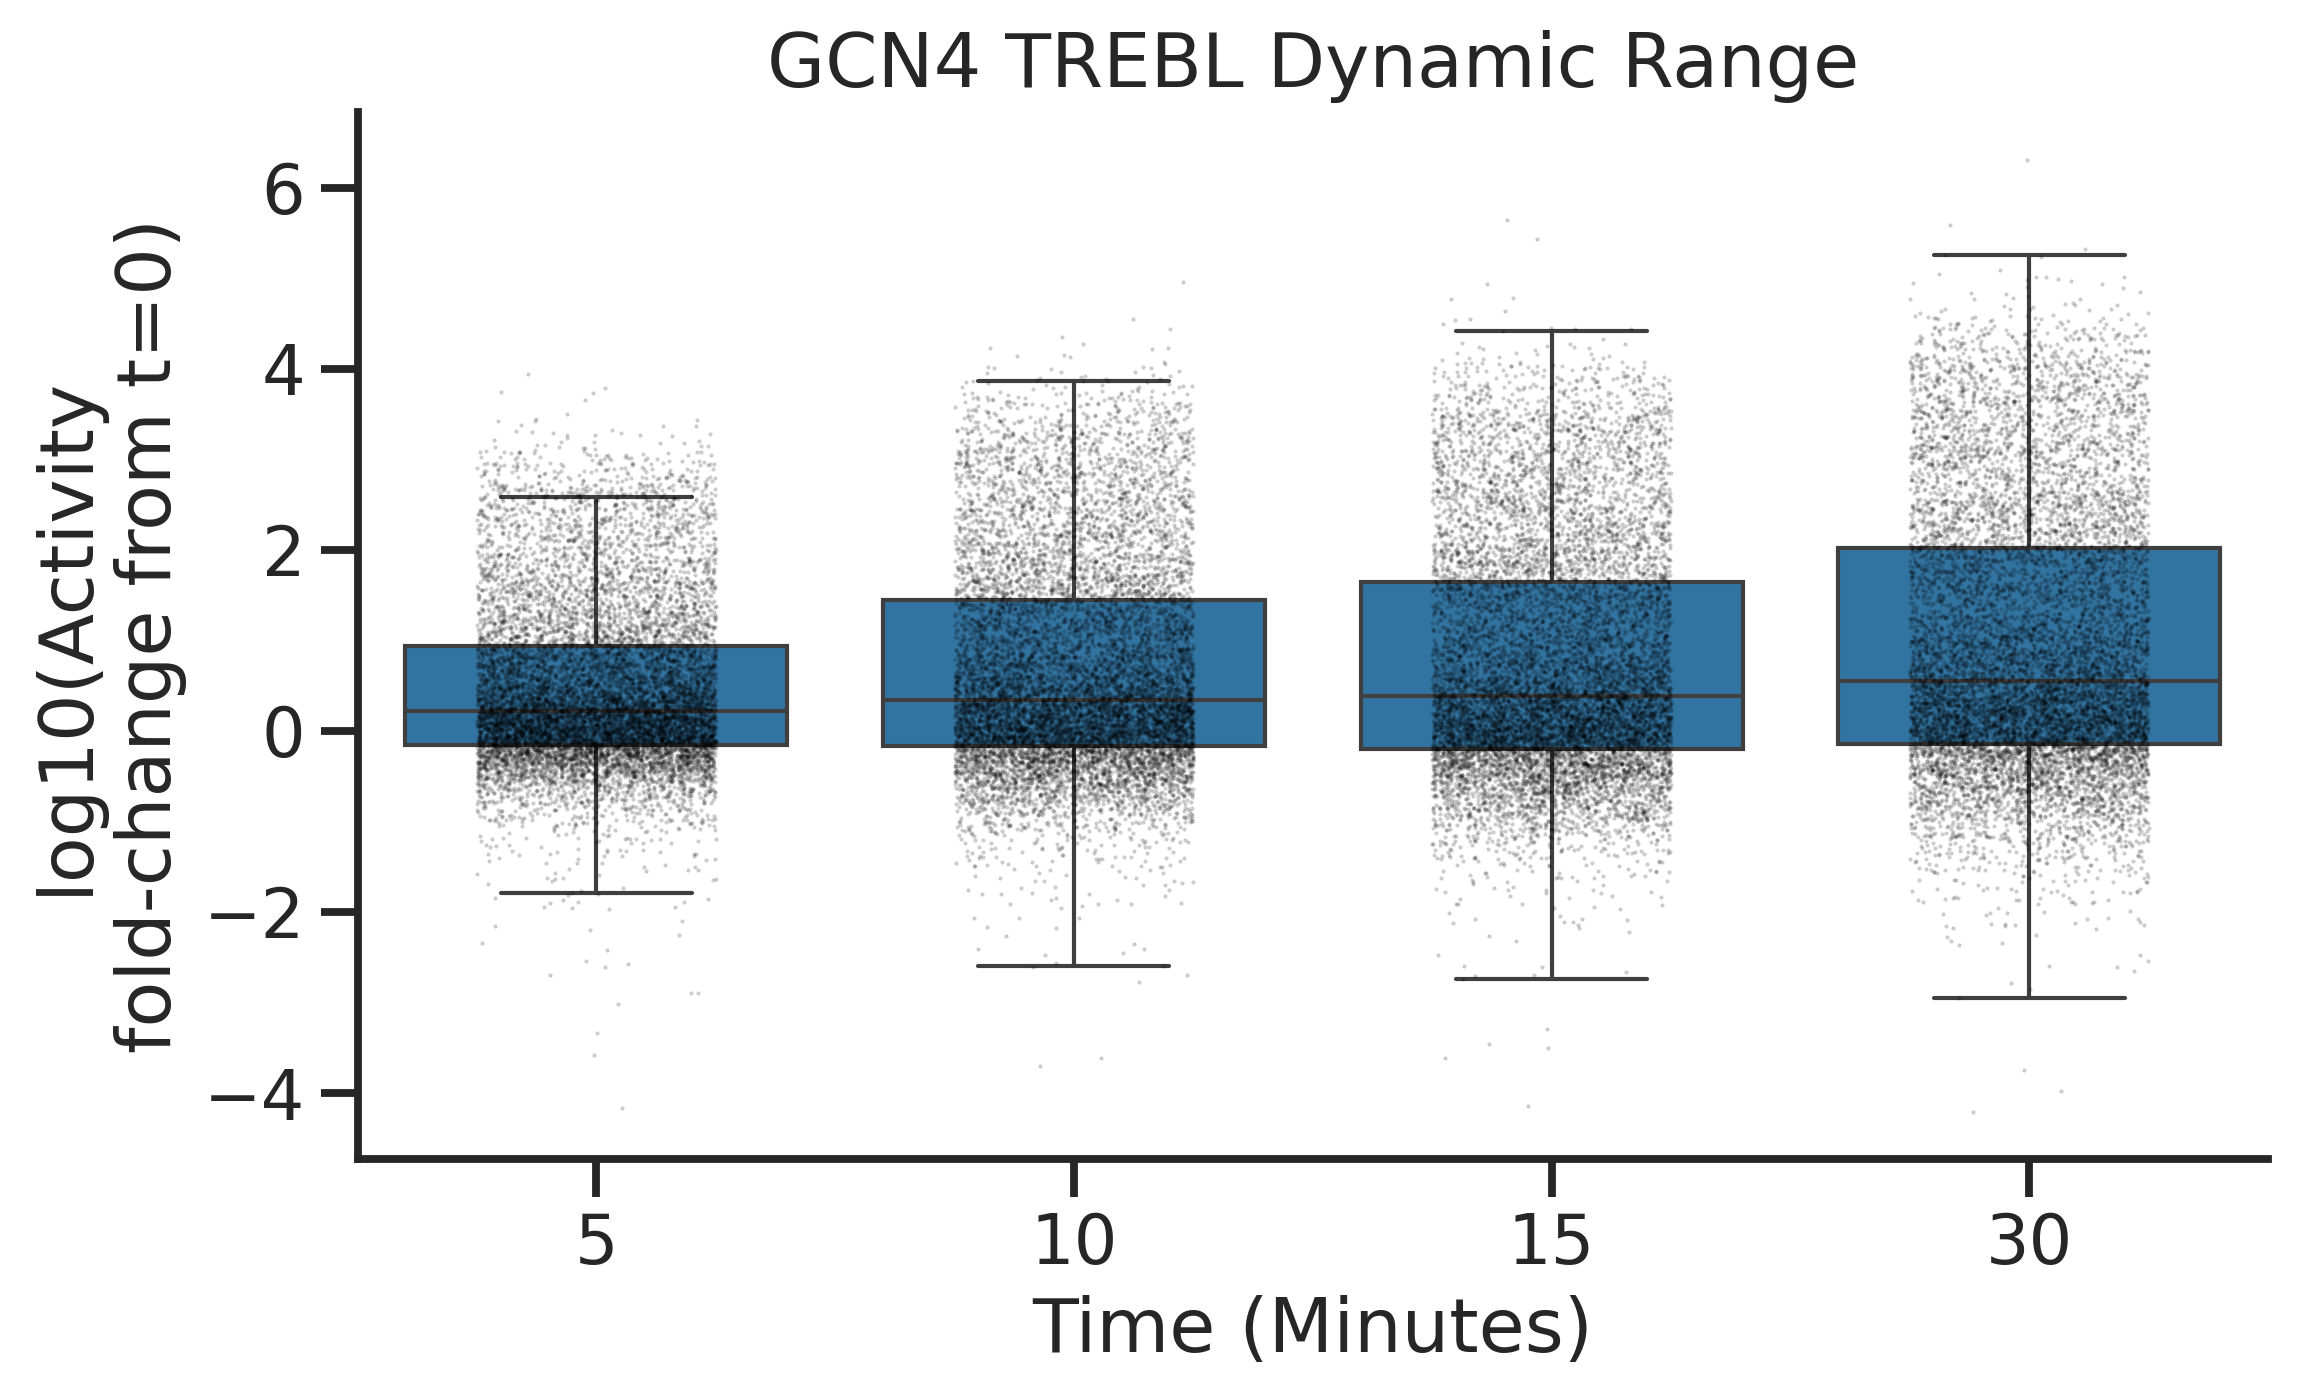

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("ticks")
sns.set_context("talk")

# distribution of rises at each time point
plot_df = tmp[tmp["time"] != 0].copy()
plot_df = plot_df[plot_df["time"] < 31]

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

sns.boxplot(
    data=plot_df,
    x="time",
    y="rise_from_t0",
    showfliers=False,
    ax=ax
)

sns.stripplot(
    data=plot_df,
    x="time",
    y="rise_from_t0",
    color="black",
    alpha=0.2,
    size=1,
    jitter=0.25,
    ax=ax
)


ax.set_xlabel("Time (Minutes)")
ax.set_ylabel("log10(Activity\nfold-change from t=0)")
plt.title("GCN4 TREBL Dynamic Range")

sns.despine()
plt.tight_layout()
plt.show()

# What is the dynamic range of ChopTFs trebl - seq?

In [51]:
df = pd.read_csv("../../output/ChopTFs_pipeline/time_normalization/DBD_time_normalized_activities_bootstrapped_error.csv")
df

,Unnamed: 0,ADseq,time,mean,ci_low,ci_hi
0,0,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,0.366271,-0.011219,0.707915
1,1,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,5,0.469570,0.204091,0.840484
2,2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,10,0.126289,-0.162042,0.268215
3,3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,15,0.189880,-0.123463,0.409278
4,4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,20,0.063215,-0.080826,0.187016
...,...,...,...,...,...,...
118808,118808,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,20,0.509707,0.421654,0.581735
118809,118809,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,30,0.647316,0.497563,0.797139
118810,118810,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,40,0.752322,0.607649,0.938344
118811,118811,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,50,0.674640,0.585810,0.770303


In [52]:
# get t=0 baseline for each tile
t0 = (
    df[df["time"] == 0]
    [["ADseq", "mean"]]
    .rename(columns={"mean": "mean_t0"})
)
t0

,ADseq,mean_t0
9,AAAAAIQEQQQLLQQKQQDDDDAIAAAAAAASSSLGDNKD,0.183722
19,AAAANNAAGPASYLSQLPQVQRYYPNNMNALSSLLDPSSA,0.129203
29,AAAASTSKSAEKEKPVTKKELKRREKQALLEKKKKLLEIA,0.092167
39,AAAKLATSGVDNITPTPAFQRRSYDISMNSSFKILPTSQA,0.164815
49,AAATTTSAPHNLSIVSPNPTYSPNPLSLYLTNSKNPLNSG,-0.098143
...,...,...
118751,YYKVGVMTAIMCLASHPKEVPEAIEVFHKVLTSFVSAKVF,0.237525
118761,YYLNVGDISAIYGVRGRIVSMAQQLRLHRCPSAVLSVHSN,0.008574
118779,YYPANGDGTTNGATPSVTSNQVQNPNLEKTYSTFEQQQQH,-0.001010
118789,YYQYPLPSNNNTINYLPSVDVQYPLNVSPSSTSHPASEVI,-0.002698


In [53]:
# merge baseline onto all rows
tmp = df.merge(t0, on="ADseq", how="left")
tmp

,Unnamed: 0,ADseq,time,mean,ci_low,ci_hi,mean_t0
0,0,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,0.366271,-0.011219,0.707915,NaN
1,1,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,5,0.469570,0.204091,0.840484,NaN
2,2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,10,0.126289,-0.162042,0.268215,NaN
3,3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,15,0.189880,-0.123463,0.409278,NaN
4,4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,20,0.063215,-0.080826,0.187016,NaN
...,...,...,...,...,...,...,...
118808,118808,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,20,0.509707,0.421654,0.581735,-0.008269
118809,118809,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,30,0.647316,0.497563,0.797139,-0.008269
118810,118810,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,40,0.752322,0.607649,0.938344,-0.008269
118811,118811,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,50,0.674640,0.585810,0.770303,-0.008269


In [54]:
# compute rise relative to t=0
tmp["rise_from_t0"] = tmp["mean"] - tmp["mean_t0"]
tmp

,Unnamed: 0,ADseq,time,mean,ci_low,ci_hi,mean_t0,rise_from_t0
0,0,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,0.366271,-0.011219,0.707915,NaN,NaN
1,1,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,5,0.469570,0.204091,0.840484,NaN,NaN
2,2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,10,0.126289,-0.162042,0.268215,NaN,NaN
3,3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,15,0.189880,-0.123463,0.409278,NaN,NaN
4,4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,20,0.063215,-0.080826,0.187016,NaN,NaN
...,...,...,...,...,...,...,...,...
118808,118808,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,20,0.509707,0.421654,0.581735,-0.008269,0.517976
118809,118809,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,30,0.647316,0.497563,0.797139,-0.008269,0.655585
118810,118810,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,40,0.752322,0.607649,0.938344,-0.008269,0.760591
118811,118811,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,50,0.674640,0.585810,0.770303,-0.008269,0.682909


In [55]:
tmp = tmp.dropna(subset = "rise_from_t0")
tmp

,Unnamed: 0,ADseq,time,mean,ci_low,ci_hi,mean_t0,rise_from_t0
9,9,AAAAAIQEQQQLLQQKQQDDDDAIAAAAAAASSSLGDNKD,0,0.183722,-0.013415,0.371072,0.183722,0.000000
10,10,AAAAAIQEQQQLLQQKQQDDDDAIAAAAAAASSSLGDNKD,2,0.352212,0.060125,0.672379,0.183722,0.168490
11,11,AAAAAIQEQQQLLQQKQQDDDDAIAAAAAAASSSLGDNKD,5,0.121406,-0.172823,0.425743,0.183722,-0.062317
12,12,AAAAAIQEQQQLLQQKQQDDDDAIAAAAAAASSSLGDNKD,10,0.316793,0.074679,0.594244,0.183722,0.133070
13,13,AAAAAIQEQQQLLQQKQQDDDDAIAAAAAAASSSLGDNKD,15,0.205854,-0.049968,0.522596,0.183722,0.022131
...,...,...,...,...,...,...,...,...
118808,118808,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,20,0.509707,0.421654,0.581735,-0.008269,0.517976
118809,118809,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,30,0.647316,0.497563,0.797139,-0.008269,0.655585
118810,118810,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,40,0.752322,0.607649,0.938344,-0.008269,0.760591
118811,118811,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,50,0.674640,0.585810,0.770303,-0.008269,0.682909


In [56]:
max_min_rise_by_time = (
    tmp[tmp["time"] != 0]
    .groupby("time")["rise_from_t0"]
    .agg(
        min_rise="min",
        max_rise="max"
    )
    .reset_index()
    .sort_values("time")
)
max_min_rise_by_time["activity_range_width"] = max_min_rise_by_time["max_rise"] - max_min_rise_by_time["min_rise"]
max_min_rise_by_time

,time,min_rise,max_rise,activity_range_width
0,2,-0.686032,0.709773,1.395805
1,5,-0.887734,1.097253,1.984987
2,10,-0.797486,1.812542,2.610028
3,15,-0.840159,2.008630,2.848789
4,20,-0.903025,2.156895,3.059920
5,30,-0.947013,2.234929,3.181943
6,40,-1.038880,2.247029,3.285910
7,50,-1.057856,2.054764,3.112619
8,60,-1.216117,2.094426,3.310543


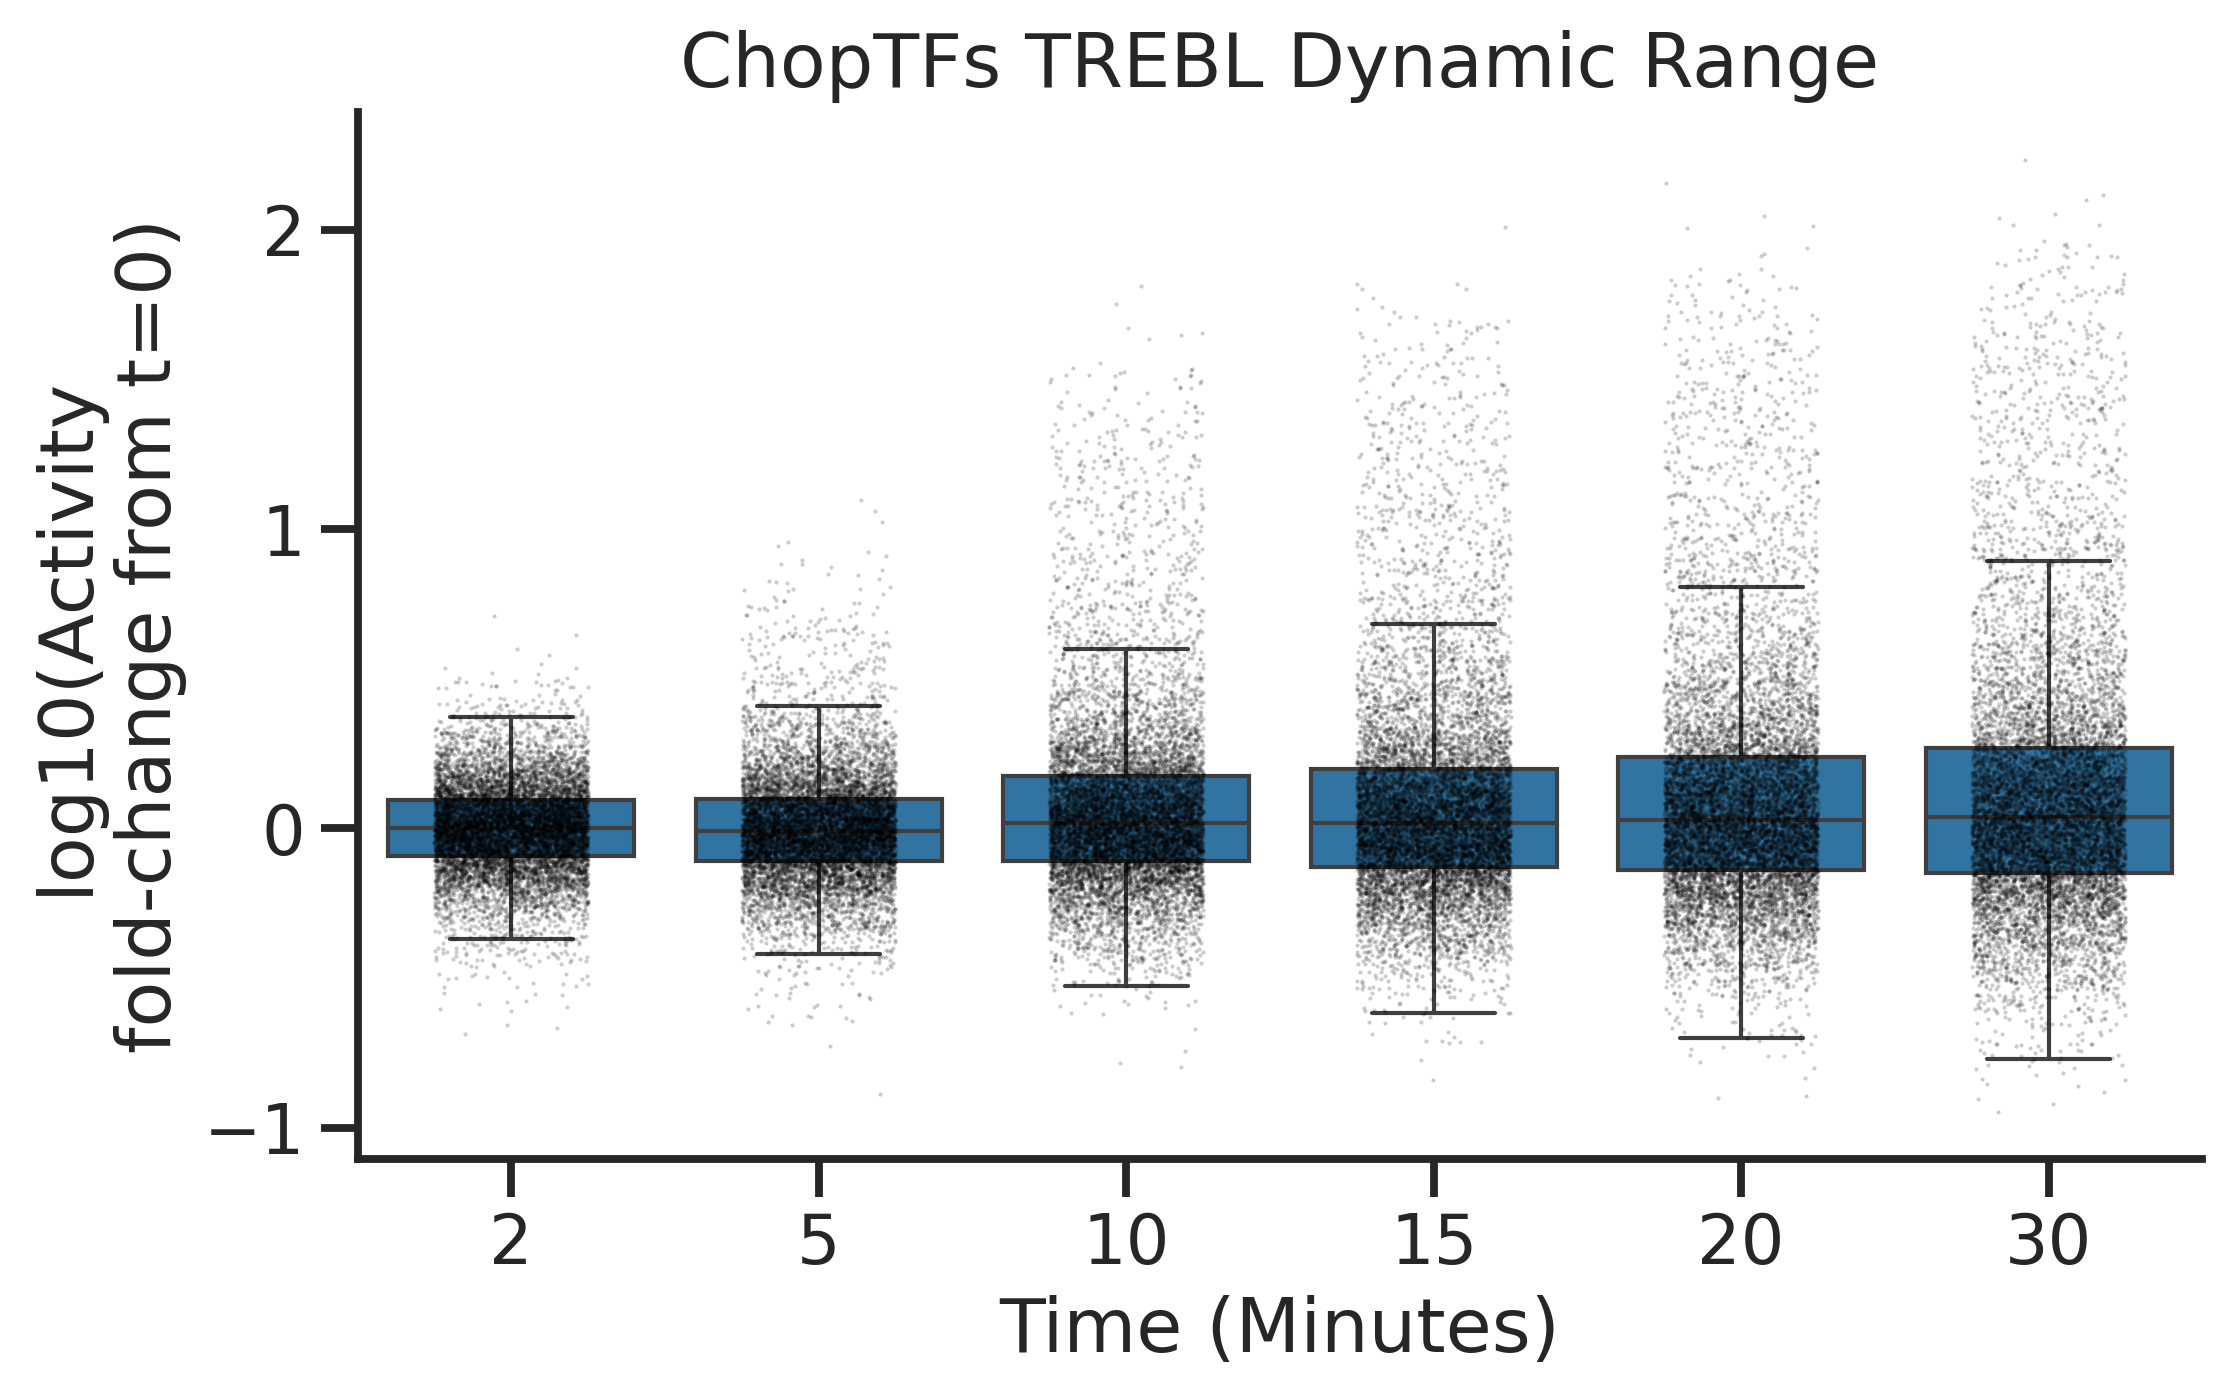

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("ticks")
sns.set_context("talk")

# distribution of rises at each time point
plot_df = tmp[tmp["time"] != 0].copy()
plot_df = plot_df[plot_df["time"] < 31]

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

sns.boxplot(
    data=plot_df,
    x="time",
    y="rise_from_t0",
    showfliers=False,
    ax=ax
)

sns.stripplot(
    data=plot_df,
    x="time",
    y="rise_from_t0",
    color="black",
    alpha=0.2,
    size=1,
    jitter=0.25,
    ax=ax
)


ax.set_xlabel("Time (Minutes)")
ax.set_ylabel("log10(Activity\nfold-change from t=0)")
plt.title("ChopTFs TREBL Dynamic Range")

sns.despine()
plt.tight_layout()
plt.show()